In [ ]:
%load_ext autoreload
%autoreload 2

Imports

In [21]:
import os
import pandas as pd
from data.creation_bdd_mains import parse_file, parse_folder
from data.creation_bdd_tournois import parse_folder_resume
from data.tri_dossier import trier_fichiers
from src.ranges import range, affichage_range
from data.chargement_txt import load_data_from_s3
from src.decision_par_position import analyse_stack_bb
from src.prediction import feature_engineering

KeyboardInterrupt: 

Import des données

In [ ]:
PROJECT_DIR = os.getcwd()

load_data_from_s3(
    project_dir=PROJECT_DIR,
    s3_path="mathiskacer2/diffusion/projet_poker/history.zip"
)

trier_fichiers("data/historique/history/", "data/mains/", "data/resumes/")


['history', '__MACOSX']


In [ ]:
tableau_mains = parse_folder ("data/mains/")
tableau_tournoi = parse_folder_resume("data/resumes/")

tableau_mains.shape
tableau_tournoi.shape

(1925, 8)

In [43]:
tableau_mains.head()
#tableau_tournoi.head()

print(tableau_mains.columns.tolist())

18297

Affichage des ranges

'metric' peut être :
- 'mean' si on veut un estimateur de l'espérance pour chaque main
- 'var' si on veut la volatilité pour chaque main
- 'freq' si on veut la fréquence d'ouverture de chaque main 

\
'hero' est le nom du joueur dont on veut afficher la range


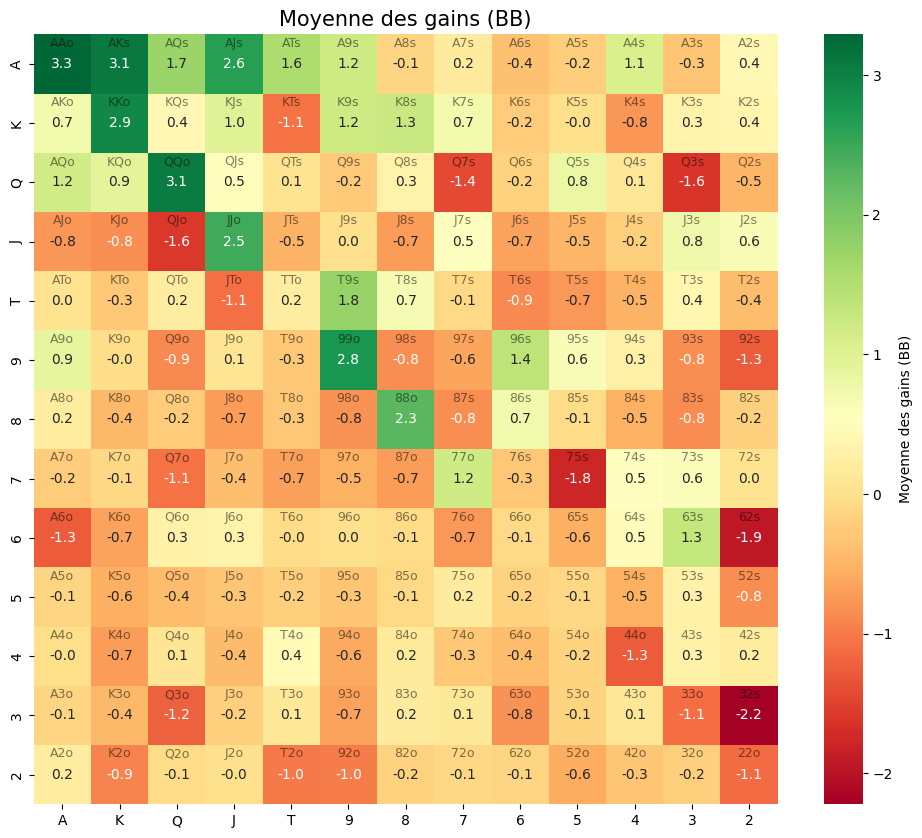

In [18]:
affichage_range(tableau_mains, metric='mean', hero='MathisKcr')

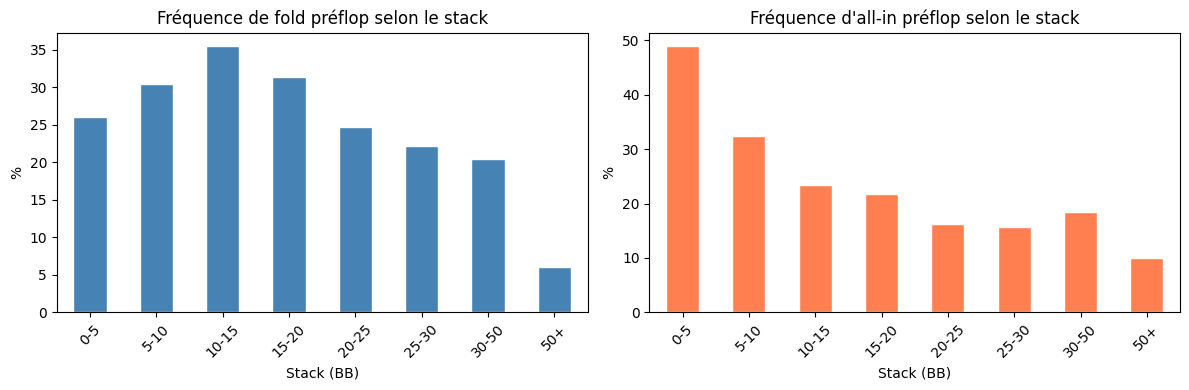

,nb_mains,fold_pf_pct,allin_pf_pct
stack_bb_range,,,
0-5,1940,0.261,0.489
5-10,4315,0.305,0.324
10-15,6747,0.355,0.234
15-20,2756,0.314,0.217
20-25,1392,0.247,0.162
25-30,528,0.222,0.157
30-50,569,0.204,0.185
50+,50,0.060,0.100


In [28]:
analyse_stack_bb(tableau_mains)

Prédiction

preprocessing

In [20]:
mains_prediction = feature_engineering(tableau_mains)

var_numeriques = ['stack_bb', 'level', 'carte haute', 'carte basse']
var_categorielles = ['position', 'main', 'est une paire', 'est meme signe', 'se suivent']

mains_prediction = mains_prediction[['benefice bb', 'main_gagnante']\
                                    + var_numeriques + var_categorielles]

mains_prediction.head()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), var_numeriques),
    ('cat', OneHotEncoder(handle_unknown='ignore'), var_categorielles)
])

KeyError: "['est meme signe'] not in index"